In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
import imageio.v2 as imageio
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cpu


In [2]:
transform = transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()])
dataset = datasets.CelebA(root="./data", split="train", download=False, transform=transform)
loader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
x0, _ = next(iter(loader))
x0 = x0.to(device)
print(f"x0 shape: {x0.shape}")   # [1, 3, 64, 64]

x0 shape: torch.Size([1, 3, 64, 64])


In [3]:
class ForwardDiffusion:
    """Reusable fixed forward process (no learning)."""

    def __init__(self, T=1000, schedule="linear", device="cpu"):  # [PLAY] defaults: T, schedule
        self.T = T
        self.device = device
        if schedule == "linear":
            betas = torch.linspace(1e-4, 0.02, T, device=device)
        elif schedule == "cosine":
            def cosine_betas(T, s=0.008):
                t = torch.arange(T + 1, device=device)
                f_t = torch.cos((t / T + s) / (1 + s) * torch.pi / 2) ** 2
                alphas_bar = f_t / f_t[0]
                return torch.clip(1 - alphas_bar[1:] / alphas_bar[:-1], max=0.999)
            betas = cosine_betas(T)
        else:
            raise ValueError(f"unknown schedule {schedule}")
        self.betas = betas
        alphas = 1 - betas
        self.alphas_bar = torch.cumprod(alphas, dim=0)     # ᾱ_t
        self.sqrt_ab = torch.sqrt(self.alphas_bar)         # √ᾱ_t
        self.sqrt_1m_ab = torch.sqrt(1 - self.alphas_bar)  # √(1−ᾱ_t)

    def q_sample(self, x0, t):
        """x_t = √ᾱ_t · x0 + √(1−ᾱ_t) · ε   (closed form from Week 7)."""
        eps = torch.randn_like(x0)
        sqrt_ab_t = self.sqrt_ab[t].view(-1, 1, 1, 1)
        sqrt_1m_t = self.sqrt_1m_ab[t].view(-1, 1, 1, 1)
        return sqrt_ab_t * x0 + sqrt_1m_t * eps, eps

    def trajectory(self, x0, n_frames=100):
        """Return x0 → x_T evenly spaced along T for animation."""
        ts = torch.linspace(0, self.T - 1, n_frames).long().to(self.device)
        frames = [x0]
        for t in ts[1:]:
            xt, _ = self.q_sample(x0, t.view(1))
            frames.append(xt)
        return ts, frames

In [4]:
fd = ForwardDiffusion(T=1000, schedule="linear", device=device)  # [PLAY] try T=500, schedule="cosine"

# (a) t = 0 must return the image unchanged (ε term has zero coefficient)
xt0, _ = fd.q_sample(x0, torch.tensor([0], device=device))
print(f"t=0 max |x0 - x_t| : {(x0 - xt0).abs().max():.2e}")   # ~0

# (b) x_T must be ~ pure noise: mean ≈ 0, std ≈ 1 per channel
xT, _ = fd.q_sample(x0, torch.tensor([fd.T - 1], device=device))
print(f"x_T mean : {xT.mean():.4f}  (target 0.0)")
print(f"x_T std  : {xT.std():.4f}  (target 1.0)")

t=0 max |x0 - x_t| : 4.19e-02
x_T mean : -0.0054  (target 0.0)
x_T std  : 1.0033  (target 1.0)


In [5]:
ts, frames = fd.trajectory(x0, n_frames=100)   # [PLAY] try n_frames=200 for a smoother GIF

imgs = []
for xt in frames:
    arr = xt[0].cpu().permute(1, 2, 0).clamp(0, 1).numpy()
    imgs.append((arr * 255).astype("uint8"))

imageio.mimsave("diffusion_destruction.gif", imgs, fps=12)  # [PLAY] try fps=24 for faster, 6 for slower
print("saved diffusion_destruction.gif")

saved diffusion_destruction.gif


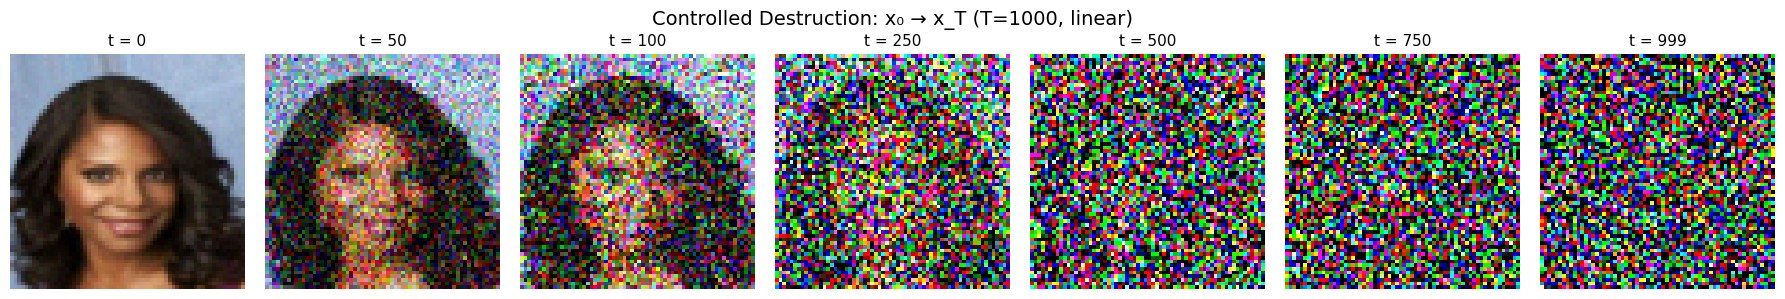

In [6]:
# Or just display a row of representative frames:
sample_steps = [0, 50, 100, 250, 500, 750, 999]  # [PLAY] try different step ranges
fig, axes = plt.subplots(1, len(sample_steps), figsize=(18, 3))
for i, t in enumerate(sample_steps):
    xt, _ = fd.q_sample(x0, torch.tensor([t], device=device))
    axes[i].imshow(xt[0].cpu().permute(1, 2, 0).clamp(0, 1))
    axes[i].set_title(f"t = {t}", fontsize=11)
    axes[i].axis("off")
plt.suptitle("Controlled Destruction: x₀ → x_T (T=1000, linear)", fontsize=14)
plt.tight_layout(); plt.show()

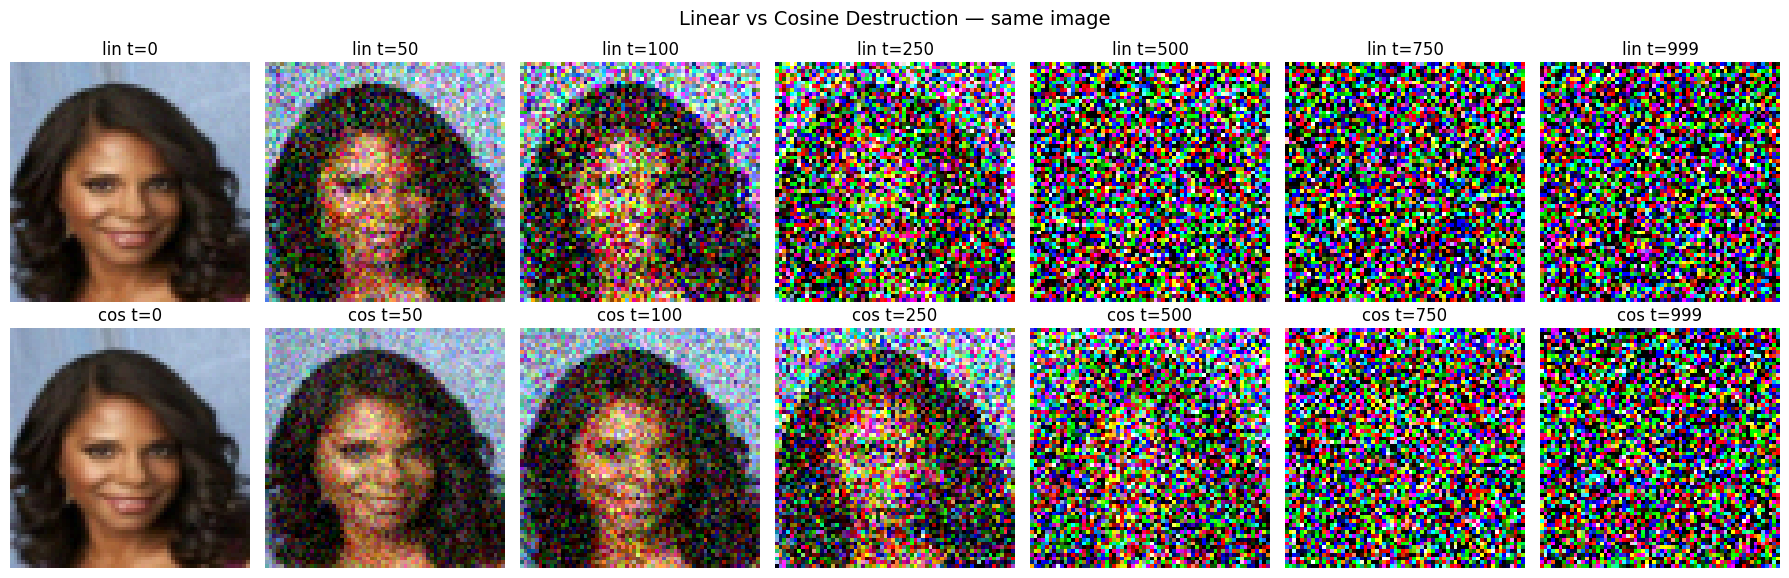

In [7]:
fd_lin = ForwardDiffusion(T=1000, schedule="linear", device=device)  # [PLAY] swap to "cosine" to compare
fd_cos = ForwardDiffusion(T=1000, schedule="cosine", device=device)  # [PLAY] default cosine here

fig, axes = plt.subplots(2, len(sample_steps), figsize=(18, 6))
for i, t in enumerate(sample_steps):
    xl, _ = fd_lin.q_sample(x0, torch.tensor([t], device=device))
    xc, _ = fd_cos.q_sample(x0, torch.tensor([t], device=device))
    axes[0, i].imshow(xl[0].cpu().permute(1, 2, 0).clamp(0, 1)); axes[0, i].set_title(f"lin t={t}"); axes[0, i].axis("off")
    axes[1, i].imshow(xc[0].cpu().permute(1, 2, 0).clamp(0, 1)); axes[1, i].set_title(f"cos t={t}"); axes[1, i].axis("off")
plt.suptitle("Linear vs Cosine Destruction — same image", fontsize=14)
plt.tight_layout(); plt.show()